In [2]:
# LOADING THE DATA
import os
import mne

data_path = "/kaggle/input/datasets/mahattasnim/chbmit"

edf_files = []

for root, dirs, files in os.walk(data_path):
    for f in files:
        if f.endswith(".edf"):
            edf_files.append(os.path.join(root, f))

print("Total EDF files:", len(edf_files))

Total EDF files: 77


In [3]:
import os
import numpy as np
import mne
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import roc_auc_score

In [4]:
def get_seizure_files(summary_path):
    
    seizure_files = []
    
    with open(summary_path, "r") as f:
        lines = f.readlines()
    
    current_file = None
    
    for line in lines:
        
        if "File Name" in line:
            current_file = line.split(":")[1].strip()
        
        if "Seizures in File" in line:
            if "0" not in line:
                seizure_files.append(current_file)
    
    return seizure_files

In [5]:
# BUILDING SEIZURE FILE LIST

seizure_file_list = []

for root, dirs, files in os.walk(data_path):
    
    for f in files:
        if "summary" in f:
            
            summary_path = os.path.join(root, f)
            
            seizure_files = get_seizure_files(summary_path)
            
            seizure_file_list.extend(seizure_files)

print("Seizure files found:", len(seizure_file_list))

Seizure files found: 22


In [6]:
# SEGMENT FUNCTION

def segment_signal(raw, window_size=3):
    
    sfreq = raw.info['sfreq']
    data = raw.get_data()
    
    samples = int(window_size * sfreq)
    
    segments = []
    
    for start in range(0, data.shape[1] - samples, samples):
        seg = data[:, start:start+samples]
        
        if seg.shape[1] == samples:
            segments.append(seg)
    
    return segments

In [7]:
# BUILDING SEGMENTS + LABELS

all_segments = []
all_labels = []

for file in edf_files:
    
    try:
        raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
    except:
        continue
    
    segments = segment_signal(raw)
    
    filename = os.path.basename(file)
    
    label = 1 if filename in seizure_file_list else 0
    
    all_segments.extend(segments)
    all_labels.extend([label] * len(segments))

print("Total segments:", len(all_segments))

/tmp/ipykernel_57/2673241489.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
/tmp/ipykernel_57/2673241489.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
/tmp/ipykernel_57/2673241489.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
/tmp/ipykernel_57/2673241489.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(file, preload=True, verbose=False)
/tmp/ipykernel_57/2673241489.py:9: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying runni

Total segments: 85450


In [8]:
print(np.unique(all_labels, return_counts=True))

(array([0, 1]), array([68345, 17105]))


In [9]:
class EEGDataset(Dataset):
    
    def __init__(self, segments, labels):
        self.segments = segments
        self.labels = labels
    
    def __len__(self):
        return len(self.segments)
    
    def __getitem__(self, idx):
        
        seg = self.segments[idx]
        
        # normalize per segment
        seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-6)
        
        seg = torch.tensor(seg, dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        return seg, label

In [10]:
dataset = EEGDataset(all_segments, all_labels)

In [11]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

In [12]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [13]:
class EEG_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv1d(23, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        
        self.fc1 = nn.Linear(64, 32)
        self.fc2 = nn.Linear(32, 1)
    
    def forward(self, x):
        
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        
        x = self.global_pool(x)
        x = x.squeeze(-1)
        
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        
        return x

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = EEG_CNN().to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [15]:
# TRAIN LOOP

epochs = 5

for epoch in range(epochs):
    
    model.train()
    total_loss = 0
    
    for X_batch, y_batch in train_loader:
        
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(X_batch).squeeze()
        
        loss = criterion(outputs, y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 438.8004
Epoch 2, Loss: 325.2687
Epoch 3, Loss: 294.1290
Epoch 4, Loss: 271.8800
Epoch 5, Loss: 254.3705


In [16]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        
        X_batch = X_batch.to(device)
        
        outputs = model(X_batch).squeeze().cpu().numpy()
        
        y_pred.extend(outputs.tolist())
        y_true.extend(y_batch.numpy())

auc = roc_auc_score(y_true, y_pred)

print("AUC:", auc)

AUC: 0.9510668682334765


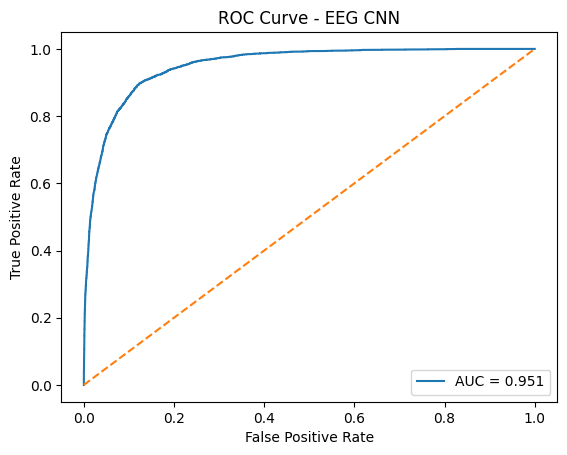

In [17]:
# ROC CURVE

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_true, y_pred)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - EEG CNN")

plt.legend()
plt.show()

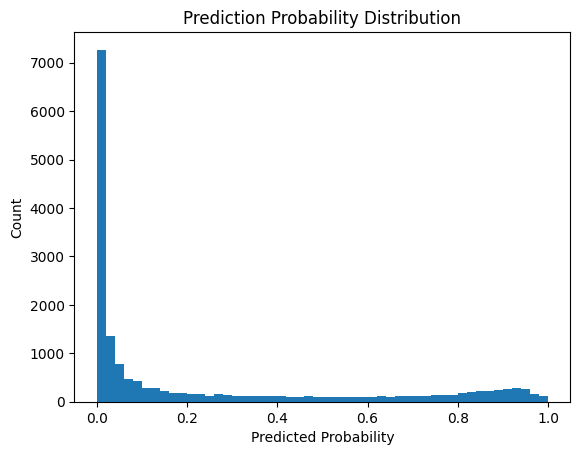

In [18]:
# PREDICTIVE DISTRIBUTION

plt.figure()
plt.hist(y_pred, bins=50)
plt.title("Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

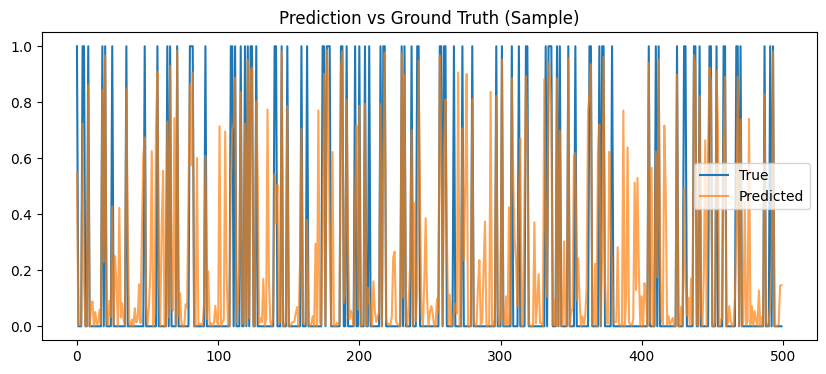

In [19]:
plt.figure(figsize=(10,4))
plt.plot(y_true[:500], label="True")
plt.plot(y_pred[:500], label="Predicted", alpha=0.7)

plt.legend()
plt.title("Prediction vs Ground Truth (Sample)")
plt.show()

In [20]:
torch.save(model.state_dict(), "cnn_pretrained.pth")

print("Model saved successfully!")

Model saved successfully!


In [21]:
import mne
import os

example_file = edf_files[0]

raw = mne.io.read_raw_edf(
    example_file,
    preload=False,
    verbose=False
)

print("CHANNEL COUNT:", len(raw.ch_names))

for ch in raw.ch_names:
    print(ch)

CHANNEL COUNT: 23
FP1-F7
F7-T7
T7-P7
P7-O1
FP1-F3
F3-C3
C3-P3
P3-O1
FP2-F4
F4-C4
C4-P4
P4-O2
FP2-F8
F8-T8
T8-P8-0
P8-O2
FZ-CZ
CZ-PZ
P7-T7
T7-FT9
FT9-FT10
FT10-T8
T8-P8-1


/tmp/ipykernel_57/1611732834.py:6: RuntimeWarning: Channel names are not unique, found duplicates for: {'T8-P8'}. Applying running numbers for duplicates.
  raw = mne.io.read_raw_edf(
